# 계열사 매출 × 경제지표 상관관계 (선별 6곳)

삼양그룹 계열사 14곳 중 **DART 공시에서 3년 이상 매출을 뽑을 수 있는 곳만** 골라
대시보드가 수집해 둔 경제지표(PostgreSQL)와 상관관계를 본다.

### 선별 결과 (`screen_affiliates.py`)

| 판정 | 계열사 | 사유 |
|---|---|---|
| 분석 | 삼양사(식품), 삼양사(화학) | 부문별 분기 매출 18개 구간 |
| 분석 | 삼양패키징 | 법인 분기 매출 23개 구간 |
| 참고만 | 삼양이노켐, 삼양데이타시스템 | 감사보고서만 → 연간 6개 구간 |
| 제외 | 삼양엔씨켐 | 연간 5개 구간 (최소 6 미달) |
| 제외 | 삼양사(코스메틱) | 보고 부문이 식품/화학/기타뿐 — 코스메틱 매출을 뗄 수 없음 |
| 제외 | 삼양홀딩스, 삼남석유화학, 삼양화성, 삼양화인테크놀로지, 삼양KCI, VERDANT | DART XML 자체가 없음 |
| 제외 | 삼양바이오팜 | 2020년 1건뿐 |

### 구성
1. 환경 설정
2. 매출 시계열 로드
3. 데이터 품질 점검 — 결측치 / 이상치
4. 상관관계 (레벨 · 변화율)
5. 시차(lag) 상관관계
6. 결론과 한계

> **주의**: 표본이 18~23개 분기(연간은 6개)로 작다. 상관계수는 확정된 관계가 아니라
> 가설 후보로만 해석할 것.

## 0. 환경 설정

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path("../..").resolve()
sys.path.append(str(ROOT / "RAG"))            # dart_parser.py
sys.path.append(str(ROOT / "dashboard" / "backend"))  # app.registry (업종별 지표 큐레이션)
sys.path.append(str(Path(".").resolve()))     # eda_utils, run_correlation

import eda_utils
import inspect_data
import run_correlation as rc

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트

load_dotenv(ROOT / "dashboard" / "backend" / ".env")
engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)
print(f"대상 {len(rc.TARGETS)}곳:", ", ".join(t[0] for t in rc.TARGETS))

대상 6곳: 삼양사(식품), 삼양사(화학), 삼양패키징, 삼양엔씨켐, 삼양이노켐, 삼양데이타시스템


## 1. 매출 시계열 로드

DART XML 82건을 매번 다시 파싱하면 몇 분씩 걸려서 `out/revenue.csv`에 캐시해 둔다.
캐시가 없으면 여기서 한 번만 만든다 (`rc.load_revenue(rebuild=True)`로 강제 재생성).

- **분기**: 분·반기보고서의 누적 매출을 차분해 구간값으로 역산 (삼양사 부문별, 삼양패키징)
- **연간**: 감사보고서 손익계산서의 매출액 (삼양이노켐, 삼양데이타시스템, 삼양엔씨켐)

In [2]:
revenue = rc.load_revenue(rebuild=False)
revenue.groupby("label").agg(
    구간수=("revenue", "size"),
    시작=("period_to", "min"),
    종료=("period_to", "max"),
    평균매출_백만원=("revenue", "mean"),
).round(0)

매출 캐시 사용: C:\sideProject\Food_Company_Sales\mandu\Eda\out\revenue.csv (--rebuild로 재생성)


C:\Users\LouisLee(이시호)\AppData\Local\Temp\ipykernel_30704\1647225685.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(0)


,구간수,시작,종료,평균매출_백만원
label,,,,
삼양데이타시스템,6,2020-12-31,2025-12-31,79764.0
삼양사(식품),18,2021-12-31,2026-03-31,382252.0
삼양사(화학),18,2021-12-31,2026-03-31,283116.0
삼양엔씨켐,5,2021-12-31,2025-12-31,100305.0
삼양이노켐,6,2020-12-31,2025-12-31,351976.0
삼양패키징,23,2020-09-30,2026-03-31,103144.0


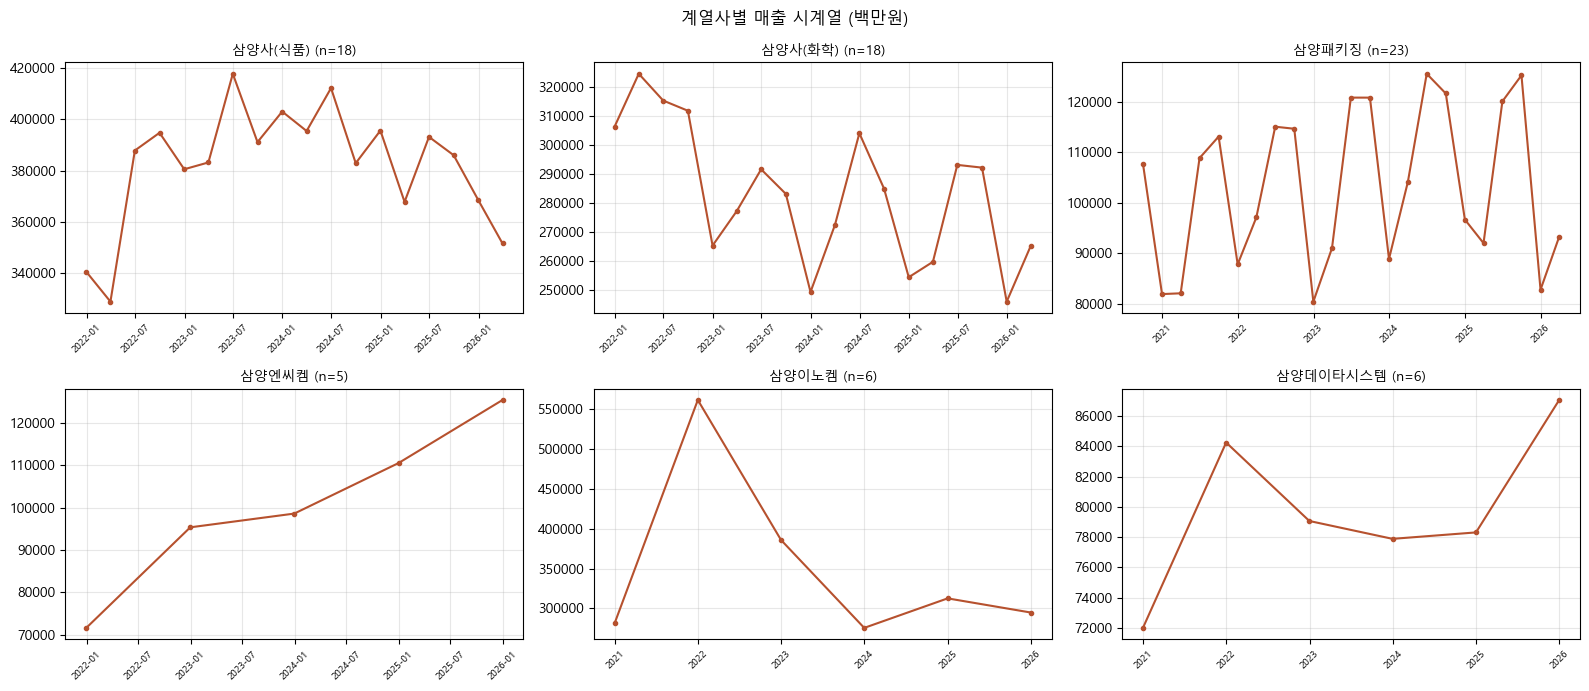

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=False)
for ax, (label, *_) in zip(axes.flat, rc.TARGETS):
    sub = revenue[revenue.label == label]
    ax.plot(sub.period_to, sub.revenue, marker="o", ms=3, color="#B6512E")
    ax.set_title(f"{label} (n={len(sub)})", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("계열사별 매출 시계열 (백만원)")
plt.tight_layout()
plt.show()

## 2. 데이터 품질 점검 — 결측치 / 이상치

이상치는 값 자체가 아니라 **전기 대비 변화량**에 MAD 기반 robust z(|z| > 5)를 씌워 잡는다.
지표 대부분이 추세를 가진 레벨 시계열이라 값에 z를 씌우면 추세 끝단이 통째로 이상치로 잡힌다.

결측 구간은 달력일이 아니라 **영업일**로 잰다 — 일별 시장지표는 주말·공휴일에 값이 없는 게 정상이라
달력일로 재면 그 공백이 전부 결측으로 잡혀 진짜 구멍이 묻힌다.

In [4]:
rev_reports = []
for label, *_ in rc.TARGETS:
    sub = revenue[revenue.label == label]
    ser = pd.Series(sub.revenue.values, index=pd.to_datetime(sub.period_to))
    rev_reports.append(inspect_data.inspect_series(f"매출::{label}", ser))

inspect_data.print_report("A. 매출 시계열", rev_reports)


A. 매출 시계열
시계열                                         빈도     n   결측   중복   0/음수   공백   이상치
------------------------------------------------------------------------------------
매출::삼양데이타시스템                                 연     6    0    0      0    0     0
매출::삼양사(식품)                                 분기    18    0    0      0    0     0
매출::삼양사(화학)                                 분기    18    0    0      0    0     0
매출::삼양엔씨켐                                    연     5    0    0      0    0     0
매출::삼양이노켐                                    연     6    0    0      0    0     0
매출::삼양패키징                                   분기    23    0    0      0    0     0


In [5]:
with engine.connect() as conn:
    points = pd.read_sql(
        text("SELECT indicator_id, series_name, date, value FROM indicator_points"),
        conn, parse_dates=["date"],
    )

ind_reports = [
    inspect_data.inspect_series(f"{i}::{s}", g.set_index("date")["value"].sort_index())
    for (i, s), g in points.groupby(["indicator_id", "series_name"])
]
print(f"지표 시계열 {len(ind_reports)}개 · 관측치 {len(points):,}개")

# 진짜 손봐야 하는 건 "한 주기 이상 통째로 빠진" 구간뿐이라 그것만 추린다.
holed = [r for r in ind_reports if r["gaps"] and r["freq"] in ("월", "분기", "연")]
inspect_data.print_report("B. 경제지표 — 결측 구간이 있는 계열", holed)

지표 시계열 135개 · 관측치 48,257개

B. 경제지표 — 결측 구간이 있는 계열
시계열                                         빈도     n   결측   중복   0/음수   공백   이상치
------------------------------------------------------------------------------------
energy_oecd_stocks::OECD 원유 재고               월   525    0    0      0   16     5
steel_prices::냉연(천원_톤)                       월    72    0    0      0    1     7
steel_prices::후판(천원_톤)                       월    72    0    0      0    1     6
steel_prices::열연(천원_톤)                       월    72    0    0      0    1     5
steel_prices::유연탄(달러_톤)                      월    72    0    0      0    1     5
steel_prices::철근(천원_톤)                       월    72    0    0      0    1     2
steel_prices::철스크랩(달러_톤)                     월    72    0    0      0    1     2
steel_prices::철광석(달러_톤)                      월    72    0    0      0    1     1
unemployment_kr_us::미국                       월    71    0    0      0    1     1
import_price_index::미국                       월    70   

### 0/음수 값은 대부분 정상값이다

증감률·경상수지·일본 기준금리는 음수가 정상이고, WTI의 음수 1건은 2020-04-20 실제
마이너스 유가다. 자동으로 지우면 안 되므로 눈으로 확인만 한다.

In [6]:
neg = [r for r in ind_reports if r["zero_or_neg"]]
pd.DataFrame([
    {"시계열": r["name"], "빈도": r["freq"], "n": r["n"], "0이하_개수": r["zero_or_neg"]}
    for r in sorted(neg, key=lambda r: -r["zero_or_neg"])
])

,시계열,빈도,n,0이하_개수
0,ecos_monthly_macro::경상수지(서비스),월,72,69
1,policy_rates::일본,월,72,43
2,ecos_gdp_growth::건설투자,분기,24,14
3,household_income_growth::사업소득,분기,25,14
4,ecos_gdp_growth::설비투자,분기,24,11
5,household_income_growth::근로소득,분기,25,11
6,household_income_growth::처분가능소득,분기,25,9
7,ecos_monthly_macro::경상수지(계),월,72,8
8,ecos_monthly_macro::경상수지(상품),월,72,8
9,household_income_growth::소득,분기,25,6


## 3. 상관관계 (레벨 · 변화율)

어떤 지표를 볼지는 백엔드 `registry.AFFILIATE_CATEGORY_INDICATOR_CATEGORIES`의 업종별
큐레이션을 그대로 쓴다 — 노트북에서 따로 적으면 대시보드와 어긋난다.

각 매출 구간에 대해 그 구간 안 지표 값의 평균을 맞춰 정렬한 뒤,
- **레벨**: 값 그대로의 상관 — 둘 다 우상향하기만 해도 크게 나온다
- **변화율**: 전기 대비 변화율의 상관 — 추세를 걷어낸 실제 연동

두 방향이 **같은 부호**로 남고 변화율 |r| > 0.3인 지표만 신호로 본다.

In [7]:
MIN_N = 6
results = {}

for label, category, *_ in rc.TARGETS:
    rev = revenue[revenue.label == label].set_index("period_to")
    ids = rc.indicator_ids_for(category)
    sub = points[points.indicator_id.isin(ids)]
    all_series = {
        f"{i}::{s}": g.set_index("date")["value"].sort_index()
        for (i, s), g in sub.groupby(["indicator_id", "series_name"])
    }
    if len(rev) < MIN_N:
        print(f"{label}: 구간 {len(rev)}개뿐이라 건너뜀 (최소 {MIN_N})")
        continue

    aligned = eda_utils.align_indicators_to_periods(rev, "revenue", all_series)
    level = eda_utils.corr_table(aligned, all_series, "revenue", min_n=MIN_N)
    pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
    change = eda_utils.corr_table(pct, all_series, "revenue", min_n=MIN_N)
    results[label] = {"aligned": aligned, "level": level, "change": change,
                      "series": all_series, "n": len(rev)}
    print(f"{label}: 구간 {len(rev)} · 지표 {len(all_series)} · 레벨 {len(level)} · 변화율 {len(change)}")

삼양사(식품): 구간 18 · 지표 33 · 레벨 29 · 변화율 29


삼양사(화학): 구간 18 · 지표 75 · 레벨 70 · 변화율 70


삼양패키징: 구간 23 · 지표 38 · 레벨 37 · 변화율 37
삼양엔씨켐: 구간 5개뿐이라 건너뜀 (최소 6)


삼양이노켐: 구간 6 · 지표 75 · 레벨 65 · 변화율 0
삼양데이타시스템: 구간 6 · 지표 61 · 레벨 51 · 변화율 0


In [8]:
def top_table(label: str, top_n: int = 12) -> pd.DataFrame:
    """레벨 상관 상위 지표에 변화율 상관을 붙이고, 둘 다 같은 부호로 남으면 '견고'로 표시."""
    r = results[label]
    chg = r["change"].set_index("indicator")["pearson"].to_dict()
    rows = []
    for _, row in r["level"].head(top_n).iterrows():
        c = chg.get(row.indicator)
        rows.append({
            "지표": row.indicator,
            "레벨_r": round(row.pearson, 2),
            "변화율_r": None if c is None else round(c, 2),
            "n": row.n,
            "견고": "*" if c is not None and c * row.pearson > 0 and abs(c) > 0.3 else "",
        })
    return pd.DataFrame(rows)

for label in results:
    print(f"\n{'=' * 70}\n{label}  (구간 {results[label]['n']}개)")
    display(top_table(label))


삼양사(식품)  (구간 18개)


,지표,레벨_r,변화율_r,n,견고
0,unemployment_kr_us::한국,-0.68,-0.14,18,
1,fao_food_price_index::Oils,-0.65,-0.10,18,
2,samyang_stock_prices::삼양사,-0.65,-0.22,18,
3,household_income_growth::소득,-0.55,-0.24,18,
4,fao_food_price_index::Sugar,0.53,0.42,18,*
5,household_income_growth::처분가능소득,-0.51,0.07,18,
6,rice_price::산지쌀가격(원/20kg),-0.45,-0.32,18,*
7,household_income_growth::근로소득,-0.45,-0.04,18,
8,livestock_prices::한우,0.45,-0.15,18,
9,unemployment_kr_us::미국,-0.38,-0.32,18,*



삼양사(화학)  (구간 18개)


,지표,레벨_r,변화율_r,n,견고
0,ecos_monthly_macro::경상수지(서비스),0.75,-0.25,18,
1,wood_import_prices::PB,0.70,0.24,18,
2,wood_import_prices::원목,0.70,0.26,18,
3,household_credit::여신전문기관(1210000),-0.70,-0.55,18,*
4,wood_import_prices::제재목,0.70,0.31,18,*
5,household_credit::판매신용,-0.69,-0.54,18,*
6,incheon_airport_stats::인바운드_여객수,-0.69,-0.17,18,
7,incheon_airport_stats::아웃바운드_여객수,-0.68,-0.18,18,
8,steel_prices::냉연(천원_톤),0.67,0.36,18,*
9,incheon_airport_stats::인바운드_운항편수,-0.66,-0.25,18,



삼양패키징  (구간 23개)


,지표,레벨_r,변화율_r,n,견고
0,retail_sales::대형마트,0.29,0.13,23,
1,incheon_airport_stats::중국발_인바운드_여객수,0.26,0.46,23,*
2,online_shopping::의복,-0.25,-0.53,23,*
3,incheon_airport_stats::중국발_인바운드_운항편수,0.25,0.31,23,*
4,energy_oil_gas::WTI,0.25,0.25,23,
5,energy_oil_gas::Brent,0.23,0.22,23,
6,incheon_airport_stats::인바운드_운항편수,0.21,-0.09,23,
7,incheon_airport_stats::아웃바운드_운항편수,0.21,-0.09,23,
8,incheon_airport_stats::아웃바운드_여객수,0.21,0.07,23,
9,incheon_airport_stats::인바운드_여객수,0.20,0.13,23,



삼양이노켐  (구간 6개)


,지표,레벨_r,변화율_r,n,견고
0,ecos_gdp_growth::민간소비,0.94,None,6,
1,wood_import_prices::제재목,0.92,None,6,
2,wood_import_prices::PB,0.89,None,6,
3,steel_prices::철광석(달러_톤),0.86,None,6,
4,wood_import_prices::원목,0.85,None,6,
5,samyang_stock_prices::삼양패키징,0.83,None,6,
6,steel_prices::열연(천원_톤),0.79,None,6,
7,steel_prices::철스크랩(달러_톤),0.78,None,6,
8,samyang_stock_prices::삼양사,0.75,None,6,
9,household_credit::상호금융,0.75,None,6,



삼양데이타시스템  (구간 6개)


,지표,레벨_r,변화율_r,n,견고
0,market_yfinance::구리(전기동),0.94,None,6,
1,ecos_monthly_macro::소비자심리지수,0.94,None,6,
2,market_yfinance::KOSPI,0.89,None,6,
3,household_credit::예금취급기관,0.85,None,6,
4,household_credit::예금은행,0.78,None,6,
5,household_credit::가계대출,0.76,None,6,
6,market_yfinance::커피,0.75,None,6,
7,household_credit::가계신용,0.74,None,6,
8,household_credit::여신전문기관(1122000),0.70,None,6,
9,ecos_gdp_growth::민간소비,0.69,None,6,


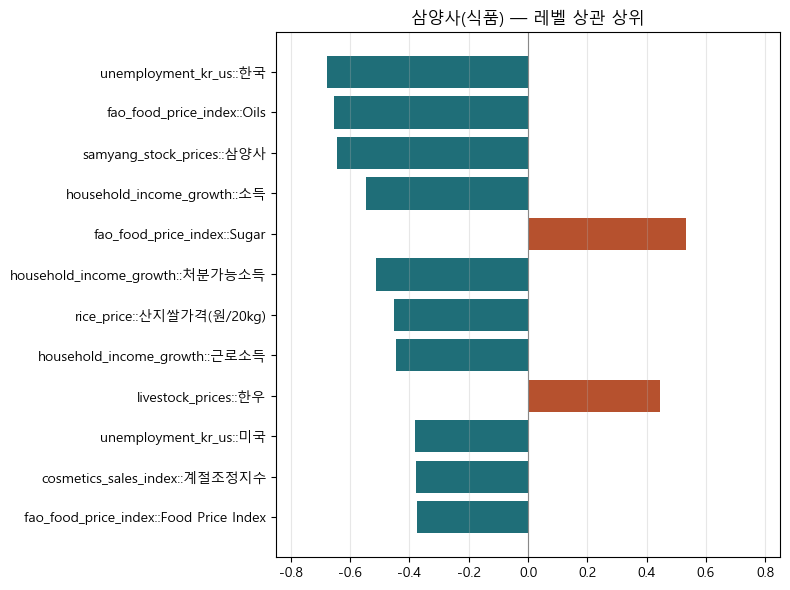

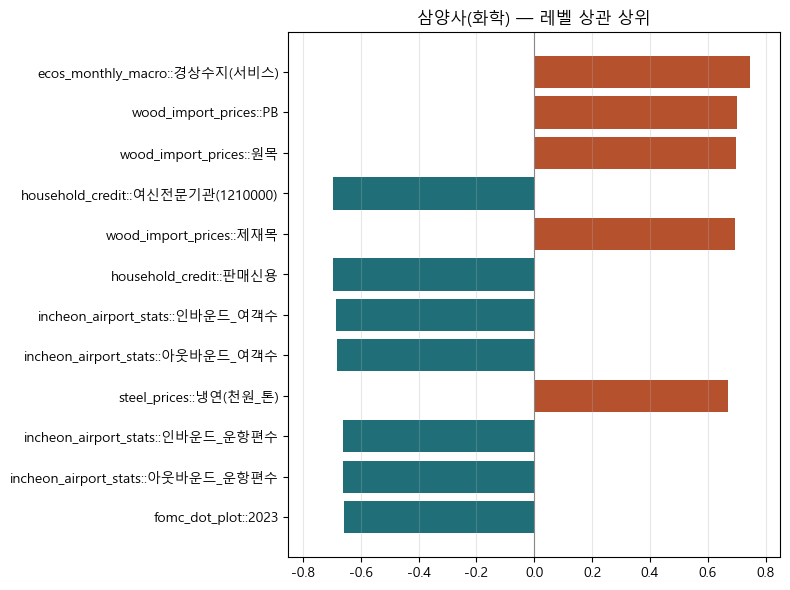

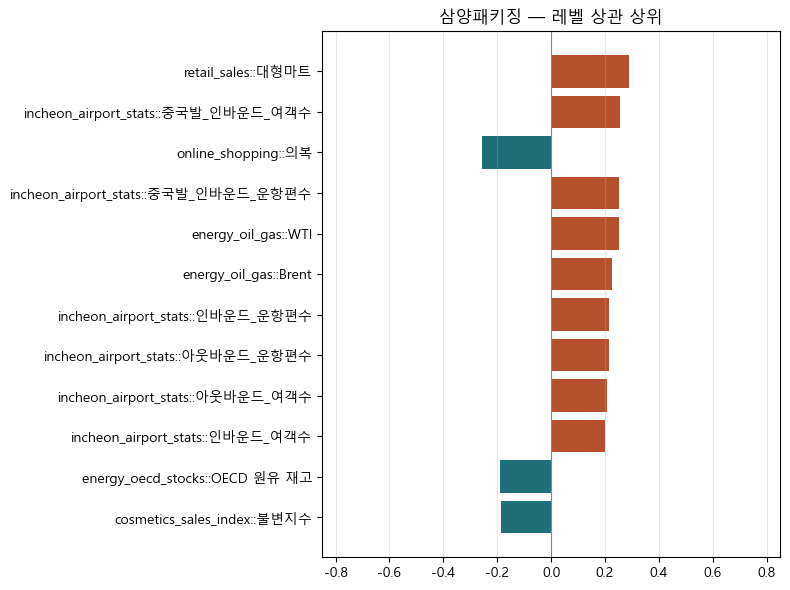

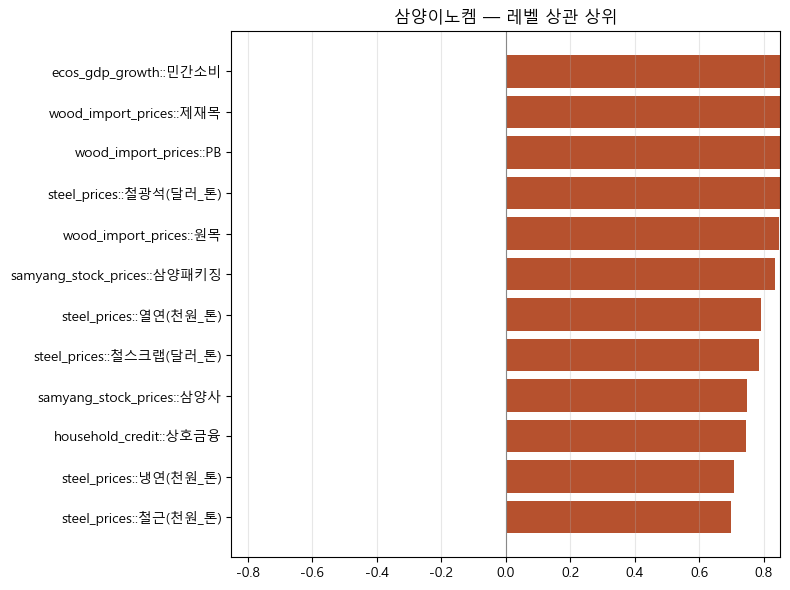

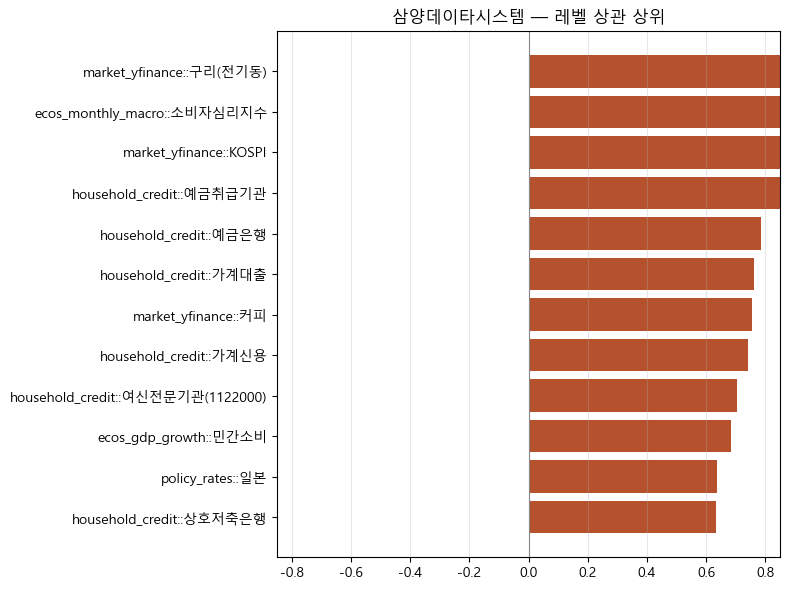

In [9]:
for label in results:
    if results[label]["level"].empty:
        continue
    eda_utils.plot_top_correlations(results[label]["level"], f"{label} — 레벨 상관 상위", top_n=12)

## 4. 시차(lag) 상관관계

지표가 t-L 구간, 매출이 t 구간일 때의 상관을 lag 0~3에 대해 계산한다.
분기 시계열이 있는 3곳만 의미가 있다 (연간 6개 구간에 lag를 걸면 표본이 3개로 줄어든다).

> 지표 × lag 조합을 모두 훑어 최댓값을 고르는 방식이라 **다중비교 문제**가 있다.
> 확정된 선행지표가 아니라 가설 후보로 취급할 것.


삼양사(식품)


C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:

,indicator,best_lag,best_corr,L0,L1,L2,L3
0,fao_food_price_index::Meat,2,-0.73,-0.01,-0.27,-0.73,-0.29
1,unemployment_kr_us::한국,1,-0.70,-0.68,-0.70,0.08,0.10
2,livestock_prices::한우,1,0.67,0.45,0.67,0.01,-0.11
3,fao_food_price_index::Oils,0,-0.65,-0.65,-0.38,-0.26,-0.18
4,samyang_stock_prices::삼양사,0,-0.65,-0.65,-0.24,0.16,0.17
5,unemployment_kr_us::미국,3,-0.62,-0.38,-0.59,-0.61,-0.62
6,household_income_growth::소득,0,-0.55,-0.55,-0.19,-0.23,-0.34
7,fao_food_price_index::Sugar,2,0.54,0.53,0.49,0.54,0.34
8,cosmetics_sales::화장품 소매판매액,2,0.53,-0.08,-0.04,0.53,0.33
9,cosmetics_sales_index::경상지수,2,0.52,-0.15,-0.13,0.52,0.34


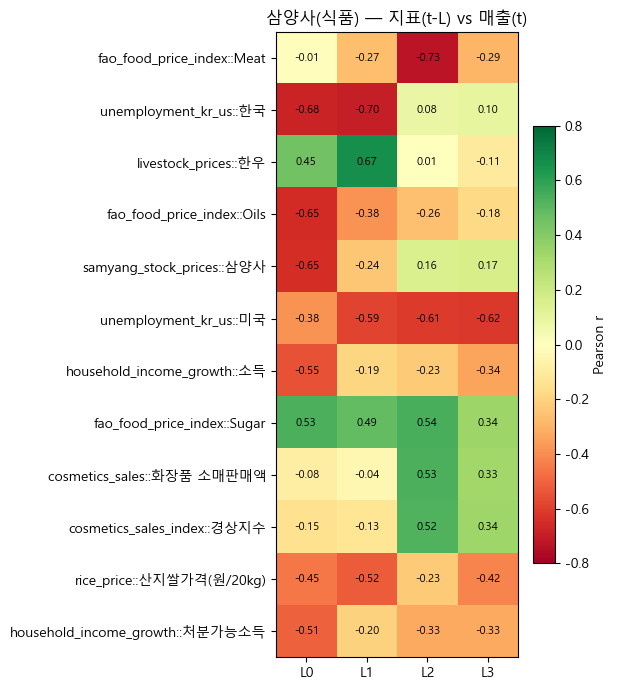


삼양사(화학)


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,fomc_dot_plot::2023,1,-0.84,-0.66,-0.84,-0.62,-0.26
1,steel_prices::철스크랩(달러_톤),1,0.80,0.51,0.80,0.28,0.01
2,ecos_monthly_macro::경상수지(서비스),0,0.75,0.75,0.56,0.37,0.32
3,household_credit::판매신용,1,-0.73,-0.69,-0.73,-0.44,-0.18
4,household_credit::여신전문기관(1210000),1,-0.72,-0.70,-0.72,-0.44,-0.17
5,fomc_dot_plot::2024,1,-0.72,-0.54,-0.72,-0.61,-0.27
6,wood_import_prices::PB,0,0.70,0.70,0.55,0.39,0.27
7,wood_import_prices::원목,0,0.70,0.70,0.65,0.24,0.27
8,wood_import_prices::제재목,0,0.70,0.70,0.64,0.40,0.33
9,incheon_airport_stats::인바운드_여객수,0,-0.69,-0.69,-0.61,-0.43,-0.28


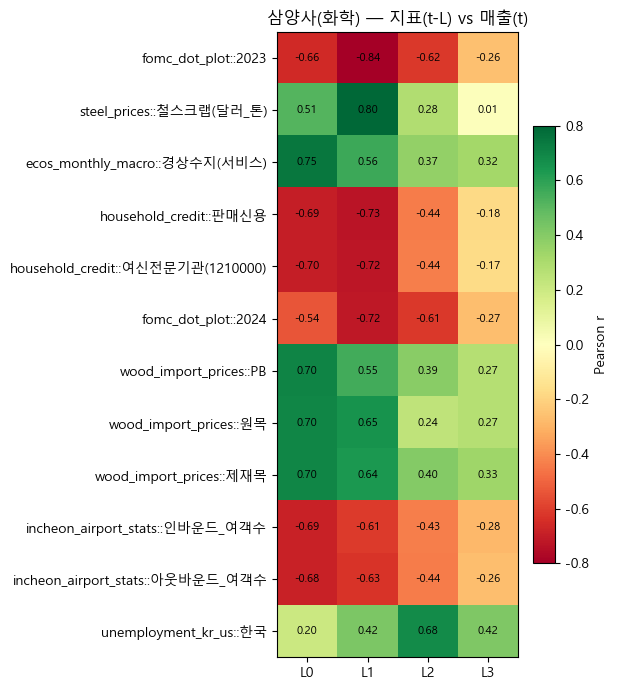


삼양패키징


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,online_shopping::의복,2,0.40,-0.25,0.13,0.40,0.26
1,steel_prices::철스크랩(달러_톤),1,0.40,-0.01,0.40,-0.00,-0.36
2,energy_oecd_stocks::OECD 원유 재고,1,-0.36,-0.19,-0.36,-0.26,-0.02
3,steel_prices::유연탄(달러_톤),1,0.35,-0.06,0.35,0.26,-0.24
4,retail_sales::백화점,2,0.35,-0.10,0.25,0.35,0.15
5,retail_sales::대형마트,3,0.32,0.29,-0.20,0.14,0.32
6,energy_oil_gas::WTI,1,0.30,0.25,0.30,0.05,-0.09
7,energy_oil_gas::Brent,1,0.29,0.23,0.29,0.06,-0.08
8,steel_prices::철광석(달러_톤),3,-0.28,-0.08,0.12,-0.12,-0.28
9,retail_sales::면세점,1,-0.28,-0.12,-0.28,-0.12,0.24


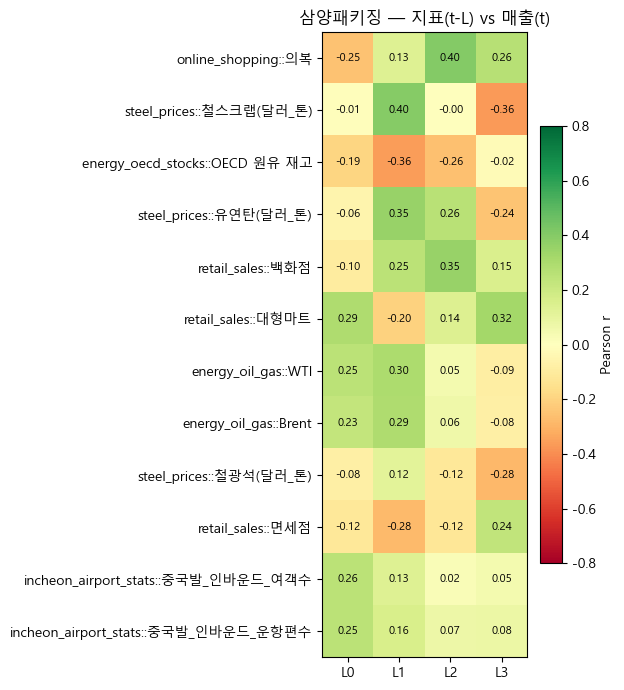

In [10]:
QUARTERLY = ["삼양사(식품)", "삼양사(화학)", "삼양패키징"]

for label in QUARTERLY:
    if label not in results:
        continue
    r = results[label]
    level_df = r["aligned"].drop(columns=["period_from"])
    lag_df = eda_utils.lag_correlation_table(level_df, r["series"], "revenue", max_lag=4, min_n=MIN_N)
    print(f"\n{'=' * 70}\n{label}")
    display(lag_df.head(10).round(2))
    if not lag_df.empty:
        eda_utils.plot_lag_heatmap(lag_df, f"{label} — 지표(t-L) vs 매출(t)", max_lag=4, top_n=12)

## 5. 결론과 한계

### 데이터 품질
- 매출 시계열: 결측·중복·이상치 **0건**. 다만 삼양사 부문별 매출은 2020~2021 상반기 공시의
  표 레이아웃이 달라 파싱에서 빠져 2021Q4부터 시작한다 (18개 구간).
- 경제지표: 진짜 결측은 `price_index_kr_us::미국`·`import_price_index::미국`의 2025-10,
  `steel_prices::*`의 2026-01 — 각각 한 달치. 분기 평균이 3개월 대신 2개월로 계산되는
  영향만 있어 그대로 뒀다. 메우려면 `python dashboard/backend/scripts/collect.py --force`.
- 일별 계열의 4~6영업일 공백은 추석·설 연휴, 다수의 "이상치"는 일간 가격 변동일 뿐이다.
  분기 평균으로 집계하는 순간 사라진다.

### 분석 한계
- **표본**: 분기 18~23개, 연간 6개. 연간 2곳(이노켐·데이타시스템)은 레벨 상관만 나오고
  변화율은 n=5로 계산조차 안 된다. 참고용 이상으로 쓰면 안 된다.
- **레벨 상관의 함정**: 매출과 지표가 둘 다 우상향하면 인과 없이도 |r| 0.7~0.9가 나온다.
  위 표의 `견고` 표시(변화율에서도 같은 부호로 남음)가 없는 항목은 추세 동조일 가능성이 크다.
- **다중비교**: 계열사마다 지표 30~75개 × lag 4개를 훑어 상위를 고른다. 우연히 강한 값이
  섞이는 걸 피할 수 없으므로, 업종 상식으로 설명되는 지표만 채택할 것.

### 다음 단계 후보
- 삼양엔씨켐: 2020~2023 감사보고서(구 "엔씨켐")에서 매출을 못 뽑은 건이 있어 구간이 5개다.
  손익계산서 파싱을 보강하면 6개 이상으로 늘릴 수 있다.
- 삼양사 부문별 매출 2020~2021 상반기: 해당 시기 표 레이아웃에 맞는 정규식을 추가하면
  구간이 18 → 23개로 늘어난다.